<a href="https://colab.research.google.com/github/qutublab/aiMATCH/blob/main/aiMATCH_Module_4_1_Cell_size_and_circularity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Determining cell sizes and circularity

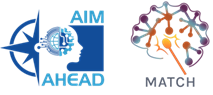

**Objective** <br>
The goal of this notebook is to introduce fundamental image processing operations using the [OpenCV](https://opencv.org/) Python library, including image loading, color space conversions (RGB → BGR → grayscale), basic thresholding, contour detection, and extraction of contour features such as area and perimeter.



**Acknowledgements** <br>
aiMATCH Hands-on Workshop Series: Computer vision for microscopy image analysis. NIH AIM AHEAD DICB Program <br>
Principal Investigator: Amina Qutub, Ph.D., University of Texas at San Antonio<br>
Workshop Presenters: David Hernandez-Guzman and Mignon Dumanjog, M.S, University of Texas at San Antonio<br> Code Author: Mignon Dumanjog, M.S., University of Texas at San Antonio<br>

**Relevant resources** <br>
[OpenCV: Image Thresholding](https://docs.opencv.org/3.4/d7/d4d/tutorial_py_thresholding.html) <br>
[OpenCV: Contours : Getting Started](https://docs.opencv.org/3.4/d4/d73/tutorial_py_contours_begin.html) <br>
[OpenCV: Contour Features](https://docs.opencv.org/4.x/dd/d49/tutorial_py_contour_features.html)



---



# Import packages


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ipywidgets import interact, IntSlider, Dropdown
import urllib.request

# Load images
Use either option 1 or option 2.

**Option 1:** Access the photos through GitHub links (no downloads necessary)

In [ ]:
# Import images
img_A_path = 'https://github.com/qutublab/aiMATCH/releases/download/CV-microscopy-workshop/CellA_Combo.jpg'
img_B_path = 'https://github.com/qutublab/aiMATCH/releases/download/CV-microscopy-workshop/CellB_Combo.jpg'
img_C_path = 'https://github.com/qutublab/aiMATCH/releases/download/CV-microscopy-workshop/CellC_Combo.jpg'

def load_image_from_url(url):
    with urllib.request.urlopen(url) as url_response:
        img_array = np.array(bytearray(url_response.read()), dtype=np.uint8)
        img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    return img

A = load_image_from_url(img_A_path)
B = load_image_from_url(img_B_path)
C = load_image_from_url(img_C_path)

# Check if images were loaded successfully
images_to_check = {'A': A, 'B': B, 'C': C}
image_paths = {'A': img_A_path, 'B': img_B_path, 'C': img_C_path}

for img_name, img_data in images_to_check.items():
    if img_data is None:
        raise FileNotFoundError(f"Error: Could not load image from {image_paths[img_name]}. Please ensure the file exists and the path is correct.")
    else:
        print(f"Image {img_name} loaded successfully.")

Image A loaded successfully.
Image B loaded successfully.
Image C loaded successfully.


**Option 2:** Locally or through Google drive



In [ ]:
# # Uncomment if accessing images via Google drive
# from google.colab import drive
# drive.mount('/content/drive')

# Import images
img_A_path = '/content/drive/MyDrive/aiMATCH Workshop Series/Module 4/CellA_Combo.jpg' # update with your file path
img_B_path = '/content/drive/MyDrive/aiMATCH Workshop Series/Module 4/CellB_Combo.jpg' # update with your file path
img_C_path = '/content/drive/MyDrive/aiMATCH Workshop Series/Module 4/CellC_Combo.jpg' # update with your file path

A = cv2.imread(img_A_path)
B = cv2.imread(img_B_path)
C = cv2.imread(img_C_path)

# Check if images were loaded successfully
images_to_check = {'A': A, 'B': B, 'C': C}
image_paths = {'A': img_A_path, 'B': img_B_path, 'C': img_C_path}

for img_name, img_data in images_to_check.items():
    if img_data is None:
        raise FileNotFoundError(f"Error: Could not load image from {image_paths[img_name]}. Please ensure the file exists and the path is correct.")
    else:
        print(f"Image {img_name} loaded successfully.")

**Once loaded, display the images**

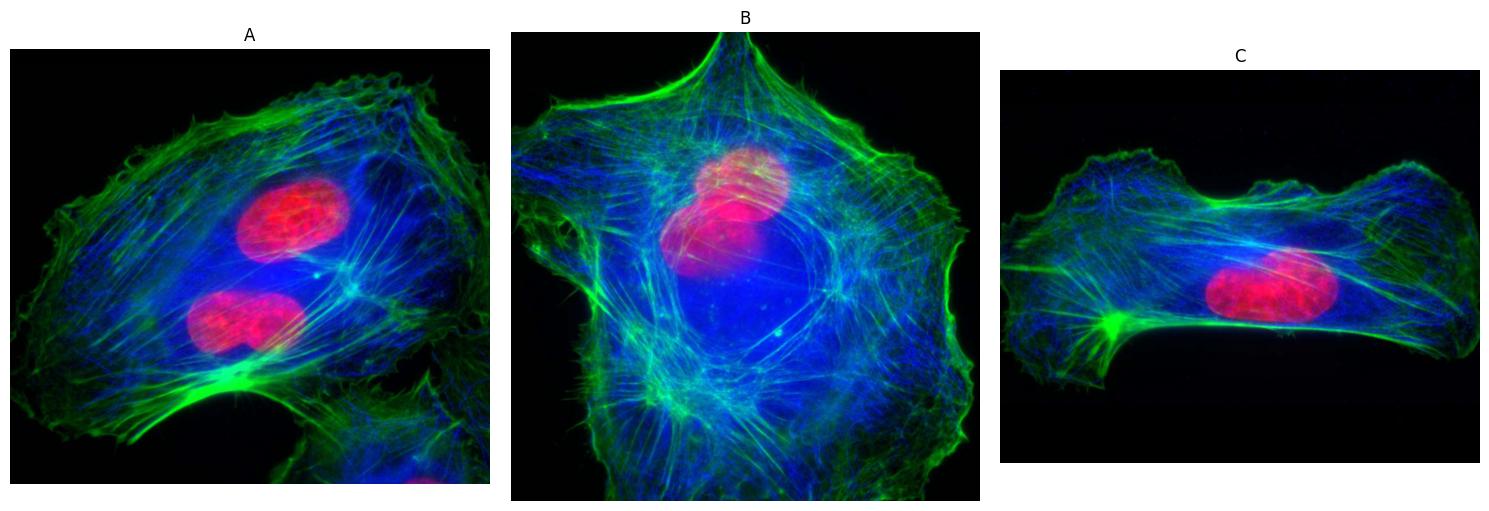

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(A)
plt.title('A')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(B)
plt.title('B')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(C)
plt.title('C')
plt.axis('off')

plt.tight_layout()
plt.show()

OpenCV conventionally loads image channels in BGR order. Let's apply the following conversion to display images in the correct RGB format.


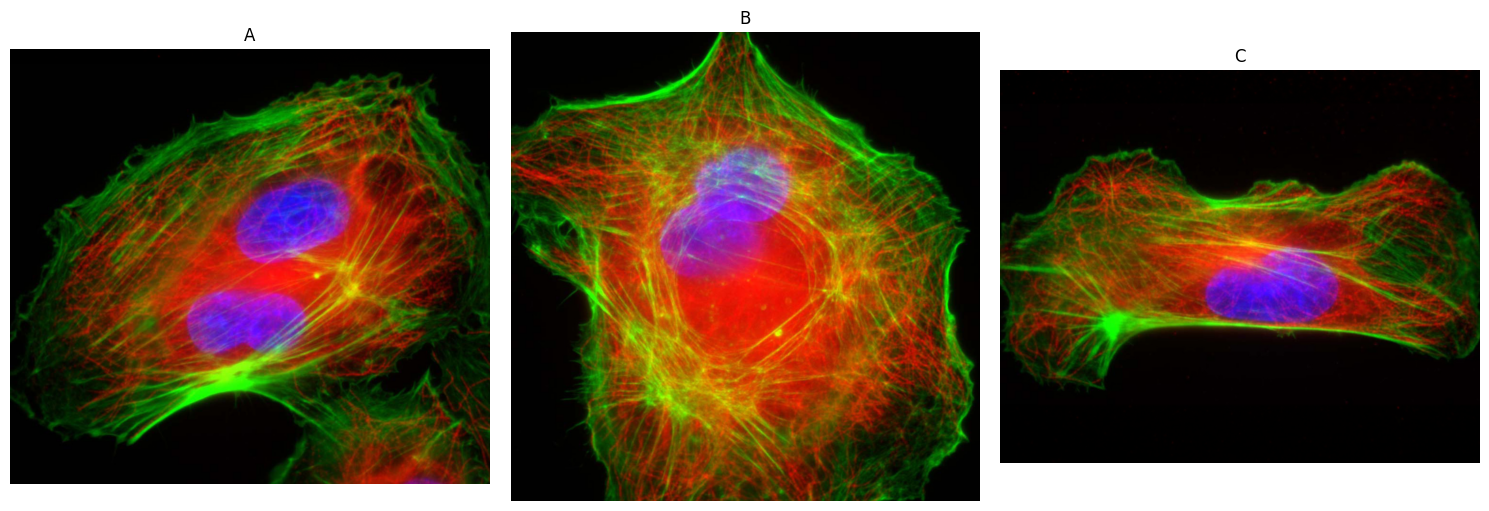

In [ ]:
A = cv2.cvtColor(A, cv2.COLOR_BGR2RGB)
B = cv2.cvtColor(B, cv2.COLOR_BGR2RGB)
C = cv2.cvtColor(C, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(A)
plt.title('A')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(B)
plt.title('B')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(C)
plt.title('C')
plt.axis('off')

plt.tight_layout()
plt.show()

# Apply grayscaling + blurring filter

Blurring is applied before contour detection to reduce noise and small intensity variations, producing smoother, more accurate contours.


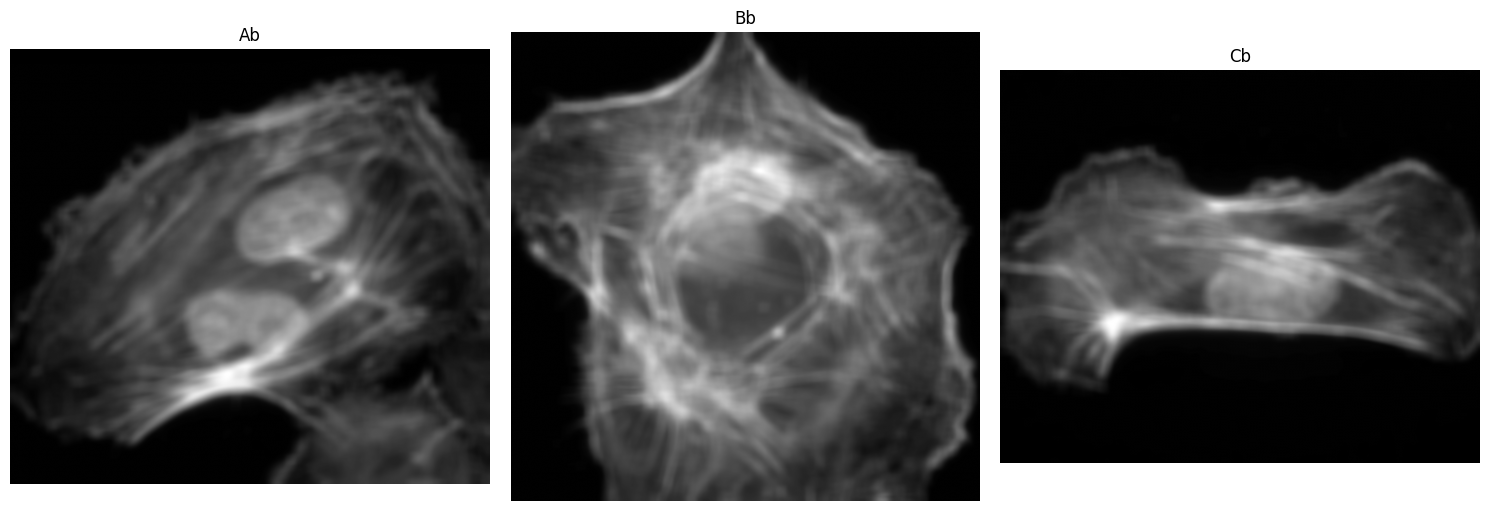

In [ ]:
Ab = cv2.blur(cv2.cvtColor(A,cv2.COLOR_BGR2GRAY), (50,50))
Bb = cv2.blur(cv2.cvtColor(B,cv2.COLOR_BGR2GRAY), (50,50))
Cb = cv2.blur(cv2.cvtColor(C,cv2.COLOR_BGR2GRAY), (50,50))

# Display grayscale blurred images Ab, Bb, and Cb
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(Ab, cmap='gray')
plt.title('Ab')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(Bb, cmap='gray')
plt.title('Bb')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(Cb, cmap='gray')
plt.title('Cb')
plt.axis('off')

plt.tight_layout()
plt.show()

# Obtain a binary (black and white) mask using thresholding
Pixel values less than the threshold will be designated background pixels  (black) and those greater than the threshold are foreground/nuclei pixels (white). We set a default threshold pixel value of *20*.

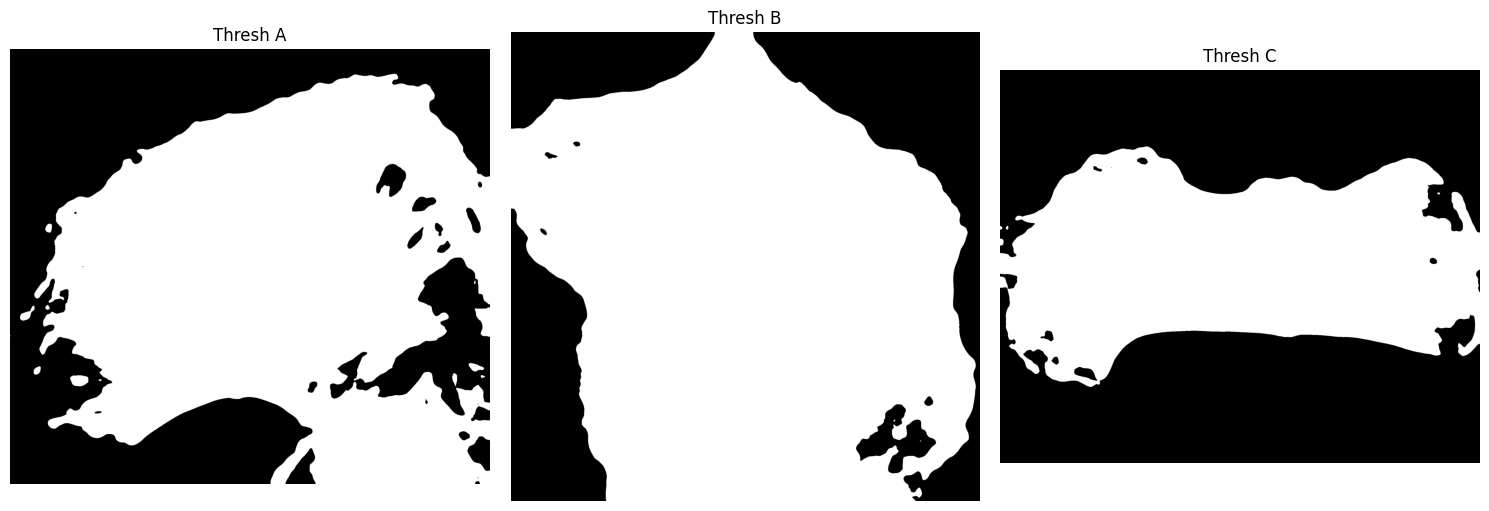

In [ ]:
# Define thresholding function

def thresh(image):
  ret, thresh = cv2.threshold(image, 20, 255, cv2.THRESH_BINARY)
  return thresh

# Apply function and define variables for the thresholded images
thresh_A = thresh(Ab)
thresh_B = thresh(Bb)
thresh_C = thresh(Cb)

# Display thresholded images
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(thresh_A, cmap='gray')
plt.title('Thresh A')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(thresh_B, cmap='gray')
plt.title('Thresh B')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(thresh_C, cmap='gray')
plt.title('Thresh C')
plt.axis('off')

plt.tight_layout()
plt.show()

Find contours, outlines of the edges where foreground and background pixels meet.

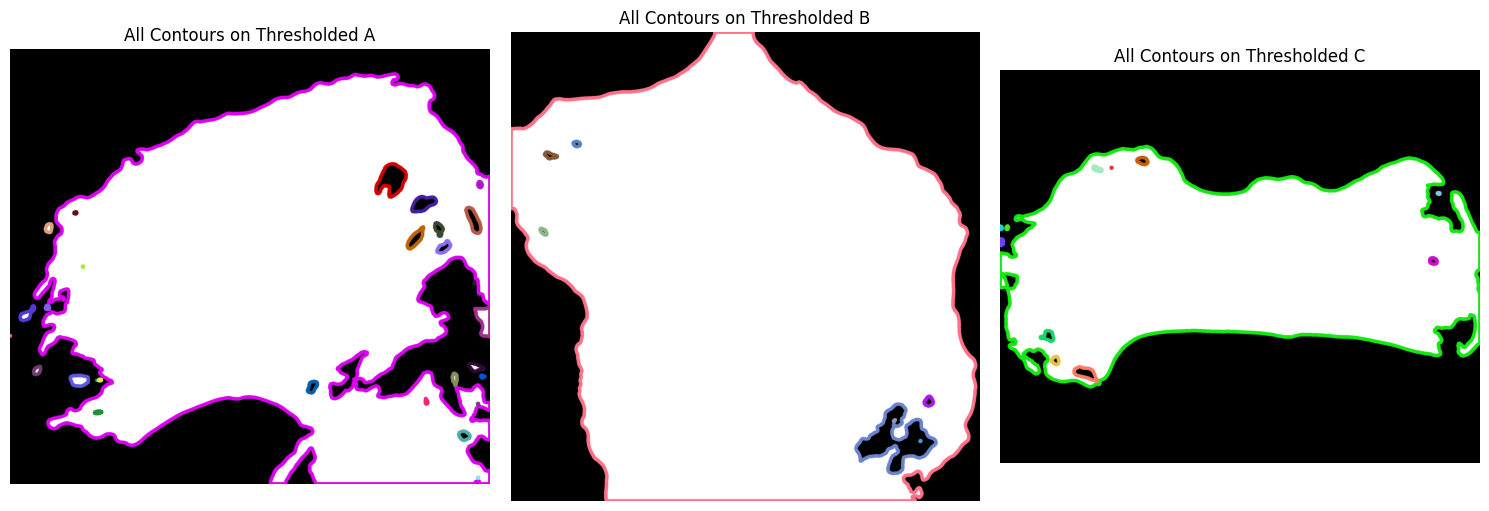

In [ ]:
import random

contours_A, __ = cv2.findContours(thresh_A, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
contours_B, __ = cv2.findContours(thresh_B, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
contours_C, __ = cv2.findContours(thresh_C, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)

# Draw all contours on copies of the thresholded images with different colors

con_A_all = cv2.cvtColor(thresh_A.copy(), cv2.COLOR_GRAY2RGB)
for i, contour in enumerate(contours_A):
    color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))
    cv2.drawContours(con_A_all, [contour], -1, color, 15)

con_B_all = cv2.cvtColor(thresh_B.copy(), cv2.COLOR_GRAY2RGB)
for i, contour in enumerate(contours_B):
    color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))
    cv2.drawContours(con_B_all, [contour], -1, color, 15)

con_C_all = cv2.cvtColor(thresh_C.copy(), cv2.COLOR_GRAY2RGB)
for i, contour in enumerate(contours_C):
    color = (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255))
    cv2.drawContours(con_C_all, [contour], -1, color, 15)

# Display all contours
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(con_A_all)
plt.title('All Contours on Thresholded A')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(con_B_all)
plt.title('All Contours on Thresholded B')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(con_C_all)
plt.title('All Contours on Thresholded C')
plt.axis('off')

plt.tight_layout()
plt.show()

Observe that there are smaller contours inside and outside the main cell area. We want to select only the largest or main contour and ignore the smaller areas. <br><br> Then, we want to calculate the area and the perimeter of the main contour, which will give us the circularity as in the equation below.

$Circularity= \frac{4π(Area)}{(Perimeter)^2}$


In [ ]:
# Define function that filters out smaller contours and obtains area & perimeter

def process_contours(contours):
  if contours:
    largest_contour = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest_contour)
    perimeter = cv2.arcLength(largest_contour, True)
    if perimeter > 0:
        circularity = 4 * np.pi * (area / (perimeter**2))
  else:
    print(f'No valid contours found for {contours}')
    largest_contour == 0, area == 0, perimeter == 0, circularity == 0

  return largest_contour, area, perimeter, circularity


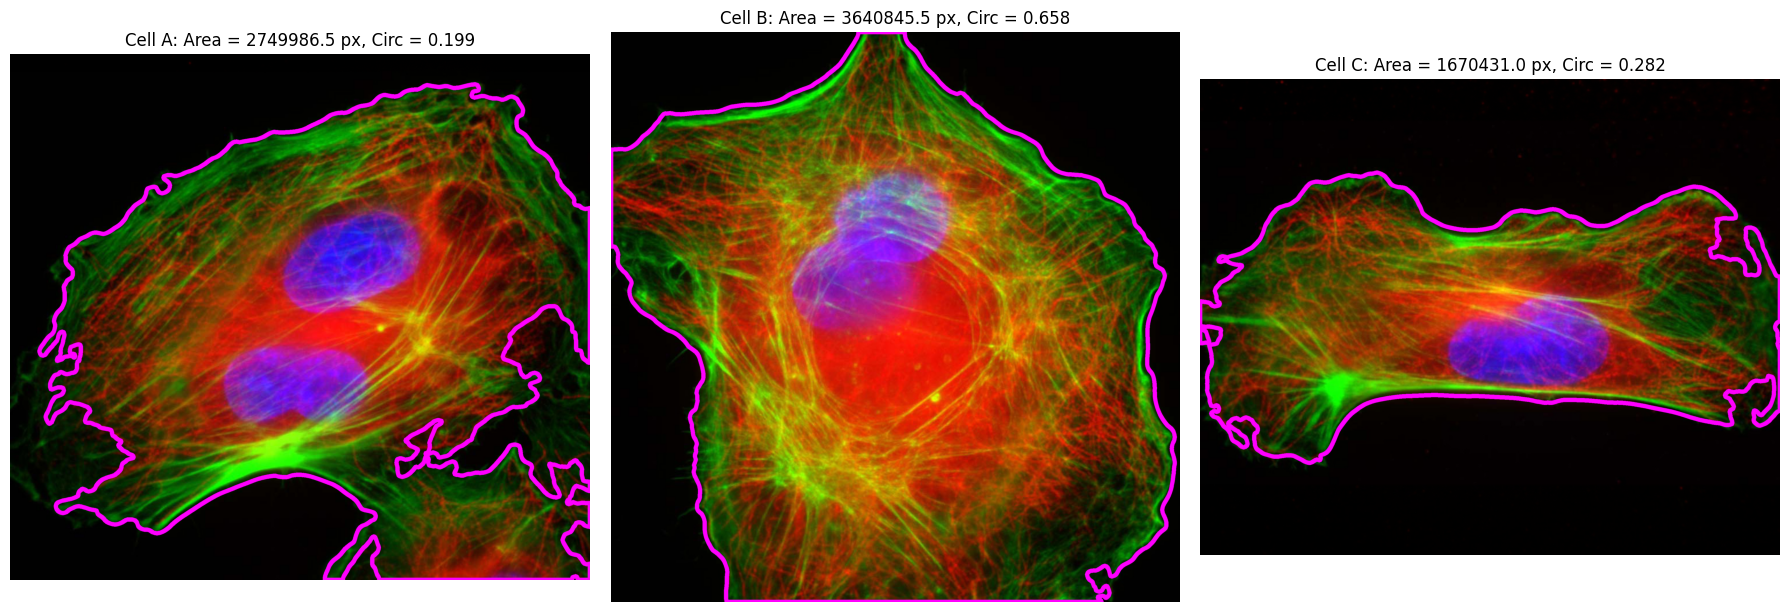

In [ ]:
# Apply function on contours
largest_contour_A, area_A, perimeter_A, circularity_A = process_contours(contours_A)
largest_contour_B, area_B, perimeter_B, circularity_B = process_contours(contours_B)
largest_contour_C, area_C, perimeter_C, circularity_C = process_contours(contours_C)

# Draw main contours
con_A = cv2.drawContours(A.copy(), [largest_contour_A], 0, (255,0,255), 15)
con_B = cv2.drawContours(B.copy(), [largest_contour_B], 0, (255,0,255), 15)
con_C = cv2.drawContours(C.copy(), [largest_contour_C], 0, (255,0,255), 15)
# (255,0,255) is magenta

# Display all contours
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(con_A)
plt.title("Cell A: Area = "+str(area_A)+" px, Circ = "+str(round(circularity_A,3)))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(con_B)
plt.title("Cell B: Area = "+str(area_B)+" px, Circ = "+str(round(circularity_B,3)))
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(con_C)
plt.title("Cell C: Area = "+str(area_C)+" px, Circ = "+str(round(circularity_C,3)))
plt.axis('off')

plt.tight_layout()
plt.show()

# Experiment!
Try varying the blur kernel and threshold values to see the effect on the final contour area

In [ ]:
def interactive_segmentation(image_name, blur_kernel, threshold_val):
    # Retrieve the original color image based on the selected name
    img = original_images_dict[image_name]

    if img is None:
        print(f"Error: Could not load image for {image_name}")
        return

    # Grayscale conversion
    # Use COLOR_RGB2GRAY because images A, B, C were already converted to RGB in a previous cell
    gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Blur
    k = max(1, blur_kernel)  # kernel must be >=1
    blur = cv2.blur(gray_img, (k, k))

    # Threshold
    _, thresh = cv2.threshold(blur, threshold_val, 255, cv2.THRESH_BINARY)

    # Contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    valid = [c for c in contours if cv2.contourArea(c) > 10000] # filter out small contours

    result_img = img.copy() # Use a copy of the original color image for drawing contours
    area, circularity = 0, 0

    if valid:
        contour = max(valid, key=cv2.contourArea)
        area = cv2.contourArea(contour)
        perimeter = cv2.arcLength(contour, True)
        if perimeter > 0:
            circularity = 4 * np.pi * area / (perimeter**2)
        else:
            circularity = 0 # Set circularity to 0 if perimeter is 0 to avoid division by zero
        # Draw contours on the original RGB image
        cv2.drawContours(result_img, [contour], -1, (255,0,255), 15)
        # (255,0,255) is magenta, 15 is the line width

    # Show images side-by-side
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(gray_img, cmap="gray")
    axes[0].set_title("Grayscale")
    axes[0].axis("off")

    axes[1].imshow(blur, cmap="gray")
    axes[1].set_title(f"Blurred (k={k})")
    axes[1].axis("off")

    axes[2].imshow(thresh, cmap="gray")
    axes[2].set_title(f"Thresholded (T={threshold_val})")
    axes[2].axis("off")

    # Display the result_img (which is already RGB)
    axes[3].imshow(result_img)
    axes[3].set_title(f"Selected Contour: Area={area:.0f}, Circ={circularity:.3f}")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

# Create a dictionary mapping string names to the original RGB images
# (A, B, C were already converted to RGB in a previous cell)
original_images_dict = {
    "Cell A": A,
    "Cell B": B,
    "Cell C": C
}

_ = interact(interactive_segmentation,
         image_name=Dropdown(options=list(original_images_dict.keys()), description="Image"), # Pass string keys as options
         blur_kernel=IntSlider(value=50, min=1, max=100, step=1),
         threshold_val=IntSlider(value=20, min=0, max=255, step=1))

interactive(children=(Dropdown(description='Image', options=('Cell A', 'Cell B', 'Cell C'), value='Cell A'), I…